In [487]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy import sparse
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
import time
import scipy.linalg
from scipy.stats import multivariate_normal
import ot

In [488]:
a=[.5,.5]
b=[.5,.5]
M=[[0.,1.],[1.,0.]]
ot.emd(a, b, M)

array([[0.5, 0. ],
       [0. , 0.5]])

In [489]:
# Generate synthetic data
mean = np.array([0,0,0])
sigma = 2
z = multivariate_normal(mean = [-3,-3,-3], cov = sigma*np.eye(3))
z2  = multivariate_normal(mean = [3,3,3], cov = sigma*np.eye(3))
blob1 = z.rvs(500)
blob2 = z2.rvs(500)
line = np.array([[-5 + 0.05 * j]*3 for j in range(200)])
rand_points = np.random.uniform(-10, 10, (1000, 3))

points = np.vstack((blob1, blob2, line, rand_points))
# points = np.vstack((rand_points))

xs, ys, zs = points[:,0], points[:,1], points[:,2]

In [490]:
xs.shape

(2200,)

In [491]:
points.shape

(2200, 3)

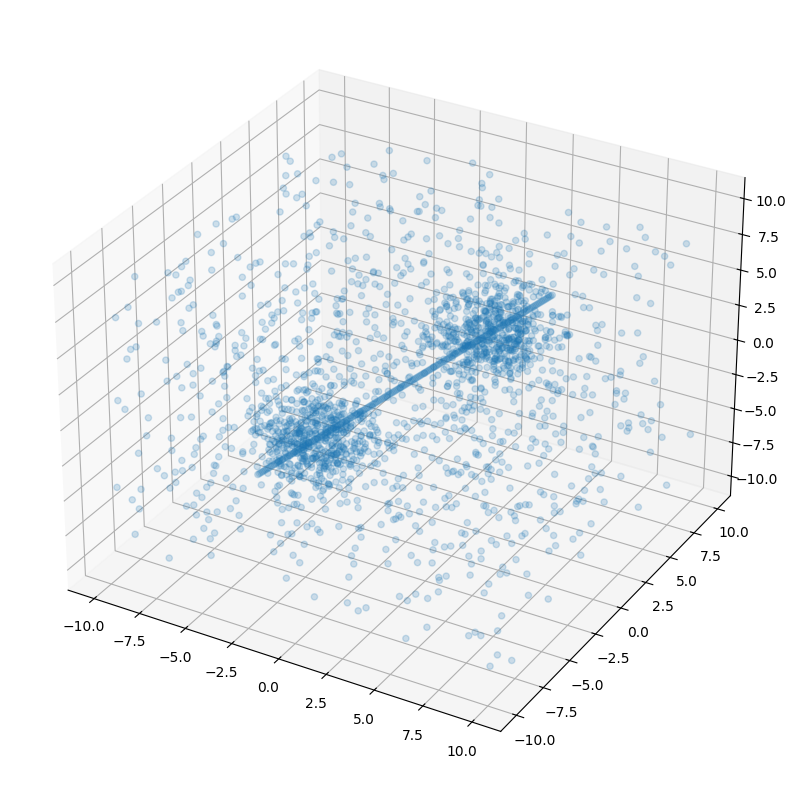

In [492]:
# Visualize data
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
ax.scatter(xs, ys, zs, alpha=0.2)
plt.show()

In [493]:
def adjust_distances(dist, boxsize):
    if dist > boxsize / 2:
        dist = boxsize - dist
    elif dist <= -boxsize / 2:
        dist = boxsize + dist
    return dist

    

In [494]:
# Periodic boundary conditions (box size 20)
def periodic_distance_matrix(xs, ys, zs, boxsize):
    points = np.vstack((xs, ys, zs)).T
    num_points = points.shape[0]
    dist_matrix = np.zeros((num_points, num_points))
    for i in range(num_points):
        delta = points - points[i]
        delta = delta - boxsize * np.round(delta / boxsize)
        dist_matrix[i] = np.sqrt(np.sum(delta**2, axis=1))
    return dist_matrix

boxsize = 20
distance_matrix = periodic_distance_matrix(xs, ys, zs, boxsize)

In [495]:
# Create a thresholded distance matrix
threshold = 0.5  # Set your desired threshold value

nearest_neighbor_matrix = np.where(distance_matrix < threshold, distance_matrix, 0)

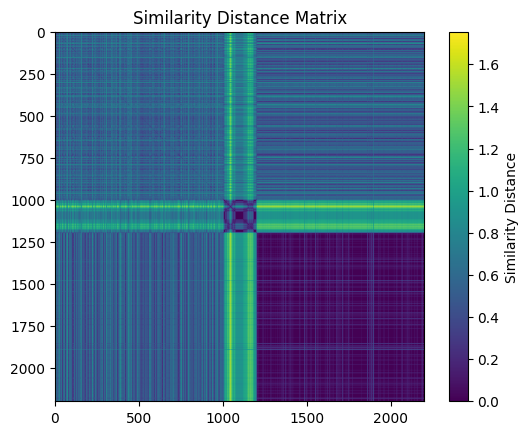

In [496]:
# Calculate similarity distances between each point's row of distances in distance_matrix
# We'll use Euclidean distance between the rows of distance_matrix

similarity_distances = euclidean_distances(np.sort(nearest_neighbor_matrix, axis=1))
plt.imshow(similarity_distances)
plt.colorbar(label='Similarity Distance')
plt.title('Similarity Distance Matrix')
plt.show()

/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


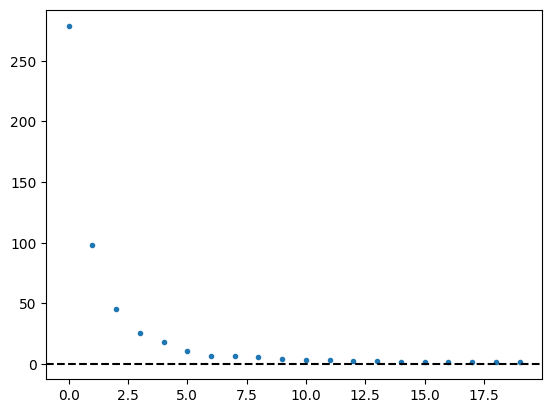

In [497]:
# Isomap embedding
D = similarity_distances
# D = wasserstein_matrix

num_points = D.shape[0]
C = np.eye(num_points) - (1 / num_points)*np.ones_like(D)
B = -0.5 * np.matmul(C, np.matmul(D, C))
evals, evecs = np.linalg.eig(B)

plt.plot(evals[:20], '.')
plt.axhline(0, color='k', linestyle='--')

In [498]:
evals[:30]

array([278.3609015 +0.j,  98.30794634+0.j,  45.43565384+0.j,
        25.39337149+0.j,  17.69025655+0.j,  10.46976994+0.j,
         6.53605778+0.j,   6.20931795+0.j,   5.61403159+0.j,
         4.10791788+0.j,   3.47788527+0.j,   2.83203786+0.j,
         2.37812438+0.j,   2.14304622+0.j,   1.95031723+0.j,
         1.80426769+0.j,   1.53350425+0.j,   1.35798753+0.j,
         1.34948785+0.j,   1.17417342+0.j,   1.12481628+0.j,
         1.04121721+0.j,   0.95761242+0.j,   0.93812356+0.j,
         0.93559751+0.j,   0.85925075+0.j,   0.82227316+0.j,
         0.72641372+0.j,   0.68970558+0.j,   0.61032769+0.j])

In [499]:
# Use only leading positive eigenvalues
num_positive = np.minimum(np.where(evals < 0)[0][0] - 1, 10)
# num_positive = 10

print(np.sum(num_positive))
num_to_keep = max(2, np.sum(num_positive))
print(f"Keeping {num_to_keep} dimensions")
X = evecs[:, :num_to_keep] * np.sqrt(evals[:num_to_keep])

10
Keeping 10 dimensions


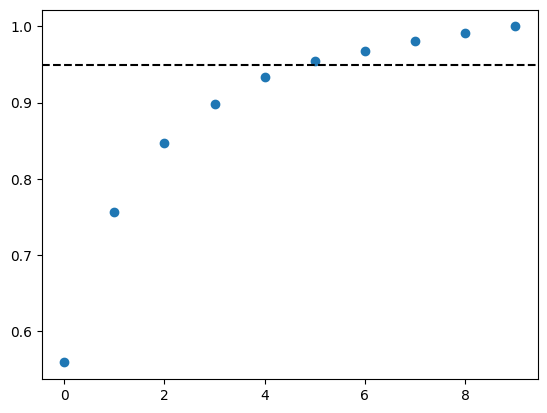

In [500]:
plt.plot(np.cumsum(evals[:num_to_keep] / np.sum(evals[:num_to_keep])), 'o')
plt.axhline(0.95, color='k', linestyle='--')

/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/matplotlib/axes/_axes.py:4590: ComplexWarning: Casting complex values to real discards the imaginary part
  c = np.asanyarray(c, dtype=float)


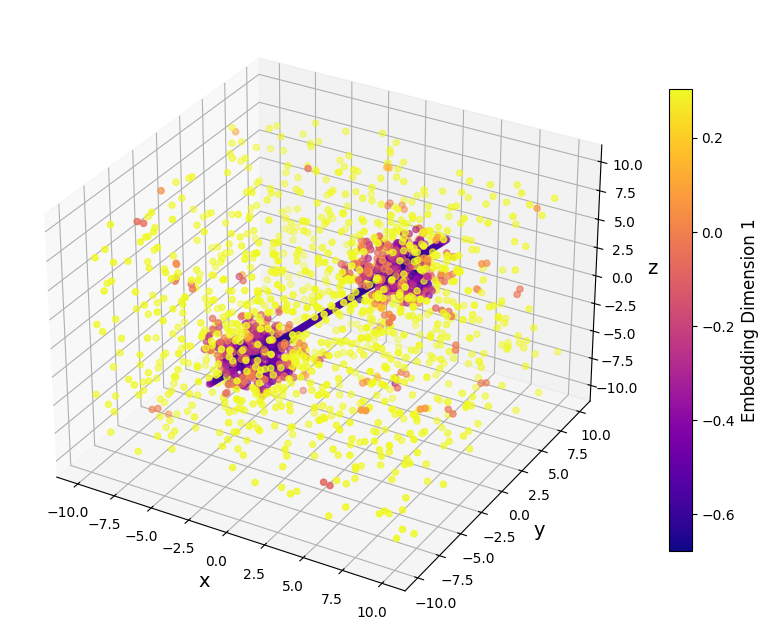

In [501]:
# PCA on Isomap embedding
# pca = PCA(n_components=3)
# embedding = pca.fit_transform(np.real(X))
# # pca.fit(np.real(X.T))

# print("Explained variance ratio:", pca.explained_variance_ratio_)
embedding = X[:, :3]  # Use the first 3 dimensions for visualization

# Visualize embedding
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
p = ax.scatter(xs, ys, zs, c=embedding[:,0], cmap='plasma')
# p = ax.scatter(xs, ys, zs, c=pca.components_[0])
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14)
cbar = fig.colorbar(p, ax=ax, shrink=0.6)
cbar.set_label("Embedding Dimension 1", fontsize=12)
plt.show()

In [502]:
# fig.savefig('simulation_embedding.pdf', bbox_inches='tight')

In [503]:
embedding[:,0]

array([ 0.11778555+0.j, -0.40659296+0.j,  0.12415501+0.j, ...,
        0.3041484 +0.j,  0.3041484 +0.j,  0.3041484 +0.j])

In [505]:
!pip install plotly

In [507]:
# Interactive plot
import plotly
import plotly.express as px
fig = px.scatter_3d(x=xs, y=ys, z=zs, color = np.real(embedding[:,0]))
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
fig.show()

# from plotly.offline import plot
# plot(fig, filename='gaussian.html', auto_open=True)
# fig.show()

ModuleNotFoundError: No module named 'plotly'

/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/numpy/lib/_histograms_impl.py:851: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/matplotlib/axes/_axes.py:7004: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16


(array([ 217.,  133.,  121.,  108.,  141.,   63.,  188.,   70.,   28.,
        1131.]),
 array([-0.67839995, -0.58014511, -0.48189028, -0.38363545, -0.28538061,
        -0.18712578, -0.08887094,  0.00938389,  0.10763873,  0.20589356,
         0.3041484 ]),
 <BarContainer object of 10 artists>)

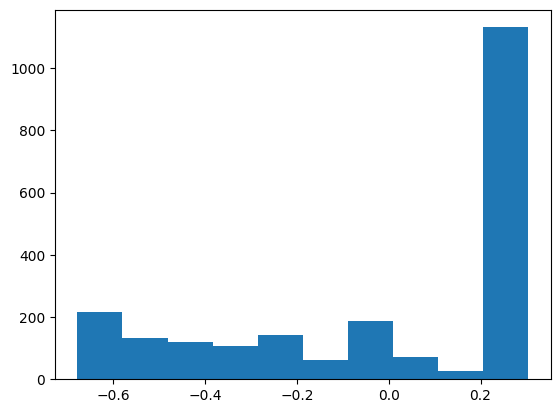

In [508]:
plt.hist(embedding[:,0], bins=10)

/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


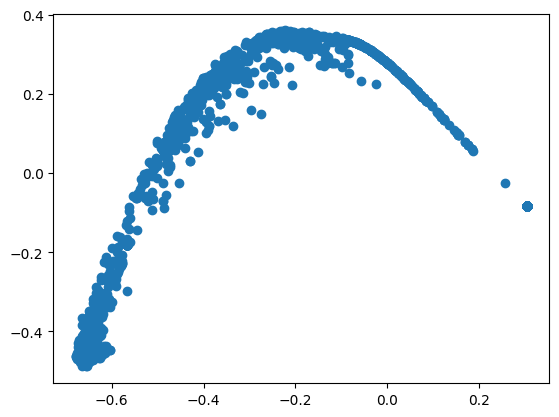

In [509]:
plt.plot(embedding[:,0], embedding[:,1], 'o')
# plt.xlabel("PCA 1")
# plt.ylabel("PCA 2")

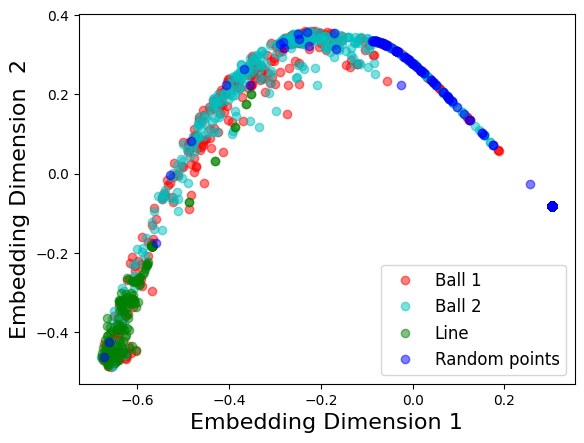

In [510]:
plt.plot(embedding[:len(blob1),0], embedding[:len(blob1),1], 'o', color='r', alpha=0.5, label="Ball 1")
plt.plot(embedding[len(blob1):(len(blob1) + len(blob2)),0], 
         embedding[len(blob1):(len(blob1) + len(blob2)),1], 'o', color='c', alpha=0.5, label="Ball 2")
plt.plot(embedding[(len(blob1) + len(blob2)):(len(blob1) + len(blob2) + len(line)),0], 
         embedding[(len(blob1) + len(blob2)):(len(blob1) + len(blob2) + len(line)),1], 'o', color='g', alpha=0.5, label="Line")
plt.plot(embedding[(len(blob1) + len(blob2) + len(line)):len(points),0],
        embedding[(len(blob1) + len(blob2) + len(line)):len(points),1], 'o', color='b', alpha=0.5, label="Random points")
plt.xlabel("Embedding Dimension 1", fontsize=16)
plt.ylabel("Embedding Dimension  2", fontsize=16)
plt.legend(fontsize=12)
plt.show()

In [511]:
def create_embedding(xs, ys, zs, boxsize = 20, threshold = 0.5):
    distance_matrix = periodic_distance_matrix(xs, ys, zs, boxsize)
    nearest_neighbor_matrix = np.where(distance_matrix < threshold, distance_matrix, 0)
    sorted_distance_vectors = np.sort(nearest_neighbor_matrix, axis=1)
    similarity_distances = euclidean_distances(sorted_distance_vectors)

    # Isomap embedding
    D = similarity_distances

    num_points = D.shape[0]
    C = np.eye(num_points) - (1 / num_points)*np.ones_like(D)
    B = -0.5 * np.matmul(C, np.matmul(D, C))
    evals, evecs = np.linalg.eig(B)

    num_positive = np.minimum(np.where(evals < 0)[0][0] - 1, 10)

    num_to_keep = max(2, np.sum(num_positive))
    print(f"Keeping {num_to_keep} dimensions")
    X = evecs[:, :num_to_keep] * np.sqrt(evals[:num_to_keep])
    embedding = X[:, :3]
    return sorted_distance_vectors, embedding


Keeping 10 dimensions
(2200, 3)


/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


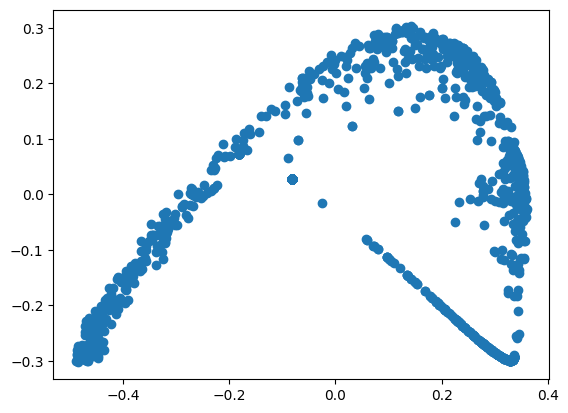

In [512]:
sorted_vectors1, e = create_embedding(xs, ys, zs)
print(e.shape)
plt.plot(e[:,1], e[:,2], 'o')

In [513]:
z_new = multivariate_normal(mean = [0,0,0], cov = 10*np.eye(3))
blob1_new = z_new.rvs(2000)
rand_points_new = np.random.uniform(-10, 10, (1000, 3))

points_new = np.vstack((blob1_new, rand_points_new))

xs_new, ys_new, zs_new = points_new[:,0], points_new[:,1], points_new[:,2]

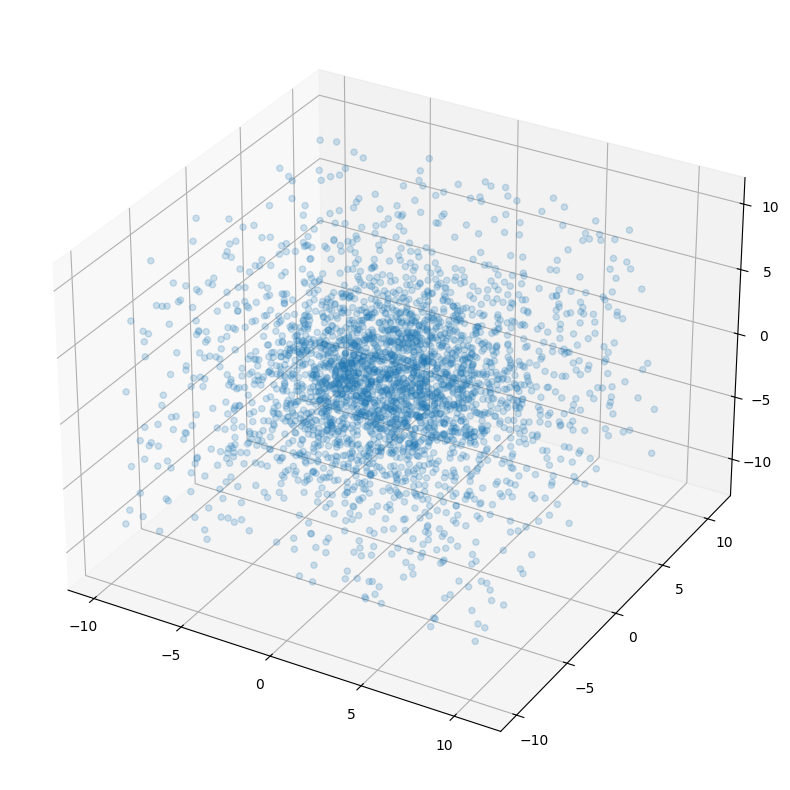

In [514]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
ax.scatter(xs_new, ys_new, zs_new, alpha=0.2)
plt.show()

Keeping 10 dimensions


/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/matplotlib/axes/_axes.py:4590: ComplexWarning: Casting complex values to real discards the imaginary part
  c = np.asanyarray(c, dtype=float)


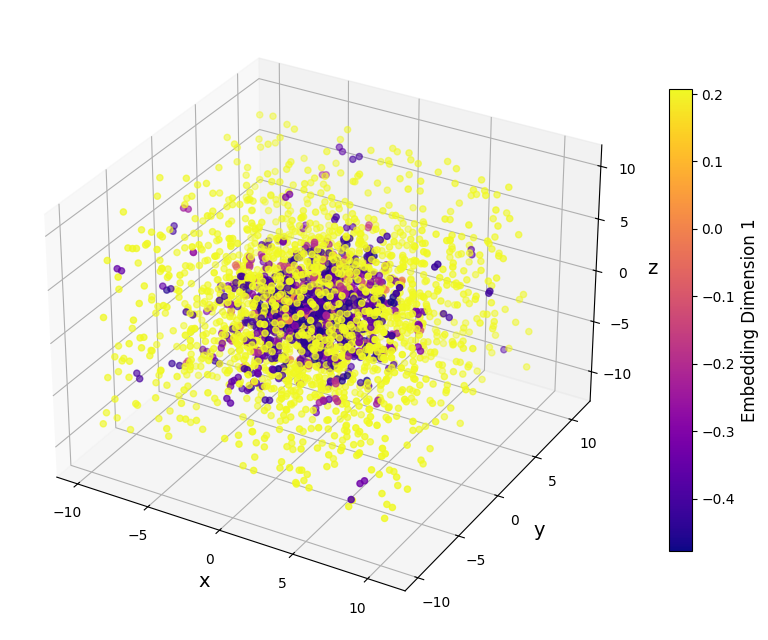

In [516]:
sorted_vectors2, new_embedding = create_embedding(xs_new, ys_new, zs_new)
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
p = ax.scatter(xs_new, ys_new, zs_new, c=new_embedding[:,0], cmap='plasma')
# p = ax.scatter(xs, ys, zs, c=pca.components_[0])
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14)
cbar = fig.colorbar(p, ax=ax, shrink=0.6)
cbar.set_label("Embedding Dimension 1", fontsize=12)
plt.show()

In [517]:
def center_and_normalize_embeddings(this_embedding):
    this_embedding = np.real(this_embedding)
    this_embedding -= np.mean(this_embedding, axis=0)
    this_embedding /= np.max(this_embedding, axis = 0)
    return this_embedding

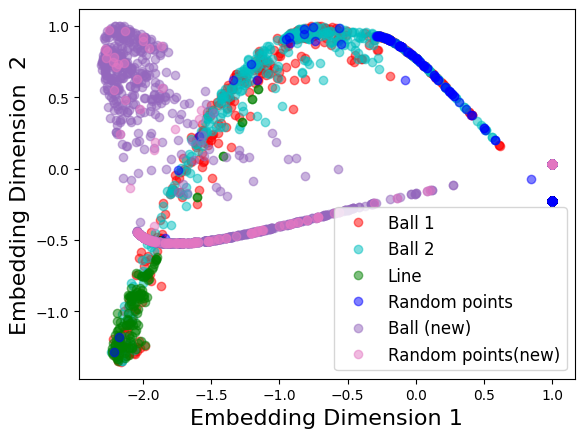

In [518]:
embedding = center_and_normalize_embeddings(embedding)
new_embedding = center_and_normalize_embeddings(new_embedding)

plt.plot(embedding[:len(blob1),0], embedding[:len(blob1),1], 'o', color='r', alpha=0.5, label="Ball 1")
plt.plot(embedding[len(blob1):(len(blob1) + len(blob2)),0], 
         embedding[len(blob1):(len(blob1) + len(blob2)),1], 'o', color='c', alpha=0.5, label="Ball 2")
plt.plot(embedding[(len(blob1) + len(blob2)):(len(blob1) + len(blob2) + len(line)),0], 
         embedding[(len(blob1) + len(blob2)):(len(blob1) + len(blob2) + len(line)),1], 'o', color='g', alpha=0.5, label="Line")
plt.plot(embedding[(len(blob1) + len(blob2) + len(line)):len(points),0],
        embedding[(len(blob1) + len(blob2) + len(line)):len(points),1], 'o', color='b', alpha=0.5, label="Random points")
plt.plot(new_embedding[:len(blob1_new),0], new_embedding[:len(blob1_new),1], 'o', color='tab:purple', alpha=0.5, label="Ball (new)")
plt.plot(new_embedding[-len(rand_points_new):,0], new_embedding[-len(rand_points_new):,1], 'o', color='tab:pink', alpha=0.5, label="Random points(new)")

plt.xlabel("Embedding Dimension 1", fontsize=16)
plt.ylabel("Embedding Dimension  2", fontsize=16)
plt.legend(fontsize=12)
plt.show()

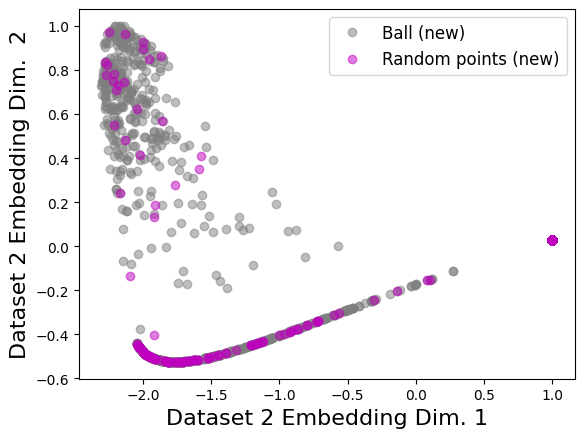

In [519]:
plt.plot(new_embedding[:len(blob1_new),0], new_embedding[:len(blob1_new),1], 'o', color='tab:gray', alpha=0.5, label="Ball (new)")
plt.plot(new_embedding[-len(rand_points_new):,0], new_embedding[-len(rand_points_new):,1], 'o', color='m', alpha=0.5, label="Random points (new)")

plt.xlabel("Dataset 2 Embedding Dim. 1", fontsize=16)
plt.ylabel("Dataset 2 Embedding Dim.  2", fontsize=16)
plt.legend(fontsize=12)
plt.show()

# Figuring things out

In [520]:
# from scipy.linalg import orthogonal_procrustes

# R, sca = orthogonal_procrustes(new_embedding, embedding)
# print(new_embedding.shape, embedding.shape, R.shape)

# transformed_embedding = np.matmul(new_embedding, R)
# plt.plot(embedding[:len(blob1),0], embedding[:len(blob1),1], 'o', color='r', alpha=0.5, label="Ball 1")
# plt.plot(embedding[len(blob1):(len(blob1) + len(blob2)),0], 
#          embedding[len(blob1):(len(blob1) + len(blob2)),1], 'o', color='c', alpha=0.5, label="Ball 2")
# plt.plot(embedding[(len(blob1) + len(blob2)):(len(blob1) + len(blob2) + len(line)),0], 
#          embedding[(len(blob1) + len(blob2)):(len(blob1) + len(blob2) + len(line)),1], 'o', color='g', alpha=0.5, label="Line")
# plt.plot(embedding[(len(blob1) + len(blob2) + len(line)):len(points),0],
#         embedding[(len(blob1) + len(blob2) + len(line)):len(points),1], 'o', color='b', alpha=0.5, label="Random points")
# plt.plot(transformed_embedding[:len(blob1_new),0],transformed_embedding[:len(blob1_new),1], 'o', color='tab:purple', alpha=0.5, label="Ball (new)")
# plt.plot(transformed_embedding[-len(rand_points_new):,0], transformed_embedding[-len(rand_points_new):,1], 'o', color='tab:pink', alpha=0.5, label="Random points(new)")

# plt.xlabel("Embedding Dimension 1", fontsize=16)
# plt.ylabel("Embedding Dimension  2", fontsize=16)
# plt.legend(fontsize=12)
# plt.show()

(25, 2)


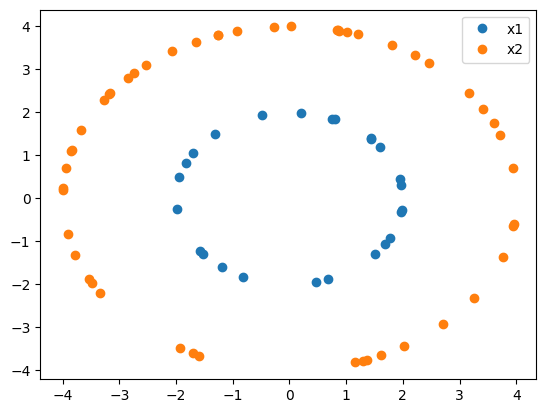

In [521]:
# Problem size
n1 = 25
n2 = 50

# Generate random data
np.random.seed(0)
a = ot.utils.unif(n1)  # weights of points in the source domain
b = ot.utils.unif(n2)  # weights of points in the target domain

x1 = np.random.randn(n1, 2)
x1 /= np.sqrt(np.sum(x1**2, 1, keepdims=True)) / 2

x2 = np.random.randn(n2, 2)
x2 /= np.sqrt(np.sum(x2**2, 1, keepdims=True)) / 4

plt.plot(x1[:,0], x1[:,1], 'o', label="x1")
plt.plot(x2[:,0], x2[:,1], 'o', label="x2")
plt.legend()

# Compute the cost matrix
C = ot.dist(x1, x2)  # Squared Euclidean cost matrix by default

print(x1.shape)



In [522]:
# Solve the OT problem
sol = ot.solve_sample(x1, x2, a, b)

# get the OT plan
P = sol.plan

# get the OT loss
loss = sol.value

# get the dual potentials
alpha, beta = sol.potentials

print(f"OT loss = {loss:1.3f}")

OT loss = 5.292


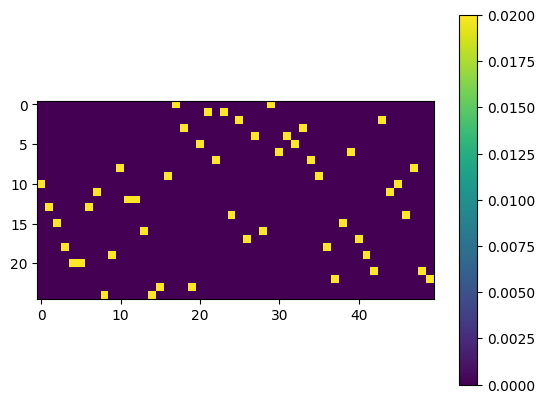

In [523]:
plt.imshow(P)
plt.colorbar()

In [524]:
P_normalized = P / P.sum(axis=1, keepdims=True)  # each row sums to 1

# Transport: weighted average of x2 points for each x1 point
x1_aligned = P_normalized @ x2  # shape (n1, 2)

x1_aligned.shape


(25, 2)

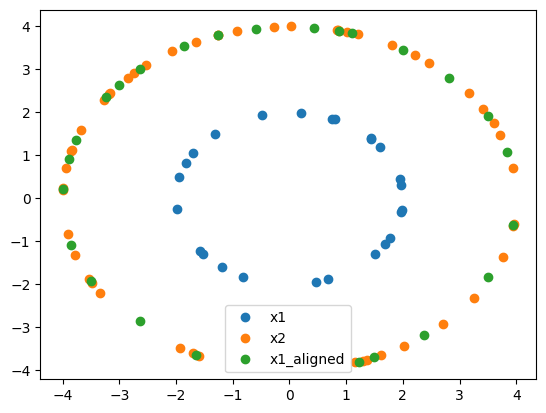

In [525]:
plt.plot(x1[:,0], x1[:,1], 'o', label="x1")
plt.plot(x2[:,0], x2[:,1], 'o', label="x2")
plt.plot(x1_aligned[:,0],x1_aligned[:,1], 'o', label="x1_aligned")

plt.legend()

# Aligning latent spaces with no info

(2200, 3) (3000, 3)
2200 3000
OT loss = 0.000


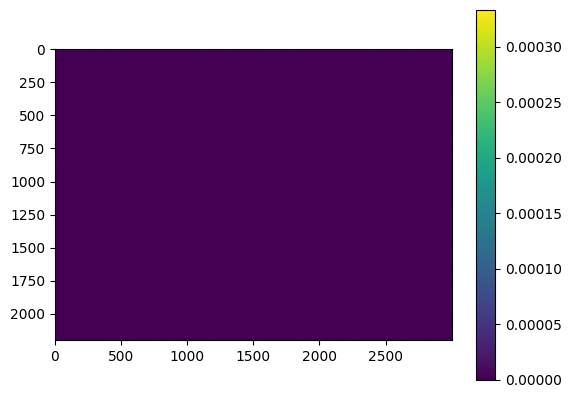

In [526]:
e1 = np.real(embedding[:, :3])    # Dataset 1: blobs + line + random
e2 = np.real(new_embedding[:, :3]) # Dataset 2: blob_new + random

# Step 1: Center both embeddings
e1_centered = e1 - e1.mean(axis=0)
e2_centered = e2 - e2.mean(axis=0)

# Step 2: Normalize scale (divide by Frobenius norm)
e1_norm = e1_centered / np.linalg.norm(e1_centered, 'fro')
e2_norm = e2_centered / np.linalg.norm(e2_centered, 'fro')

print(e1_norm.shape, e2_norm.shape)

a = ot.utils.unif(len(e1[:,0]))  # weights of points in the source domain
b = ot.utils.unif(len(e2[:,0]))

print(len(a), len(b))

# Solve the OT problem
sol = ot.solve_sample(e1_norm, e2_norm, a, b)

# get the OT plan
P = sol.plan

# get the OT loss
loss = sol.value

# get the dual potentials
alpha, beta = sol.potentials

print(f"OT loss = {loss:1.3f}")

plt.imshow(P)
plt.colorbar()
plt.show()


In [527]:
P_normalized = P / P.sum(axis=1, keepdims=True)  # each row sums to 1

# Transport: weighted average of x2 points for each x1 point
e1_aligned = P_normalized @ e2_norm  # shape (n1, 2)

P_normalized_T = P.T / P.T.sum(axis=1, keepdims=True)  # each row sums to 1

e2_aligned = P_normalized_T @ e1_norm

e1_aligned.shape

(2200, 3)

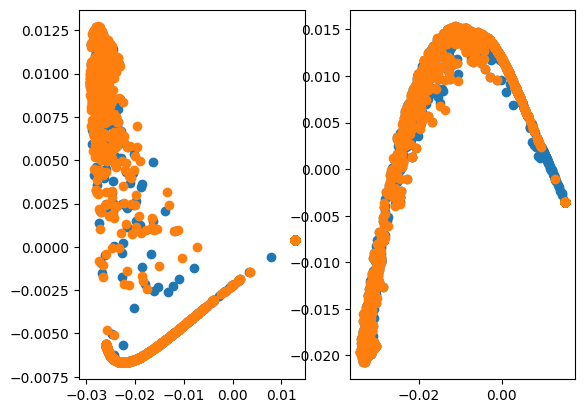

In [528]:
fig, ax = plt.subplots(1,2)

ax[0].plot(e1_aligned[:,0], e1_aligned[:,1], 'o')
ax[0].plot(e2_norm[:,0], e2_norm[:,1], 'o')
# plt.plot(e1_norm[:,0], e1_norm[:,1], 'o')

ax[1].plot(e2_aligned[:,0], e2_aligned[:,1], 'o')
ax[1].plot(e1_norm[:,0], e1_norm[:,1], 'o')

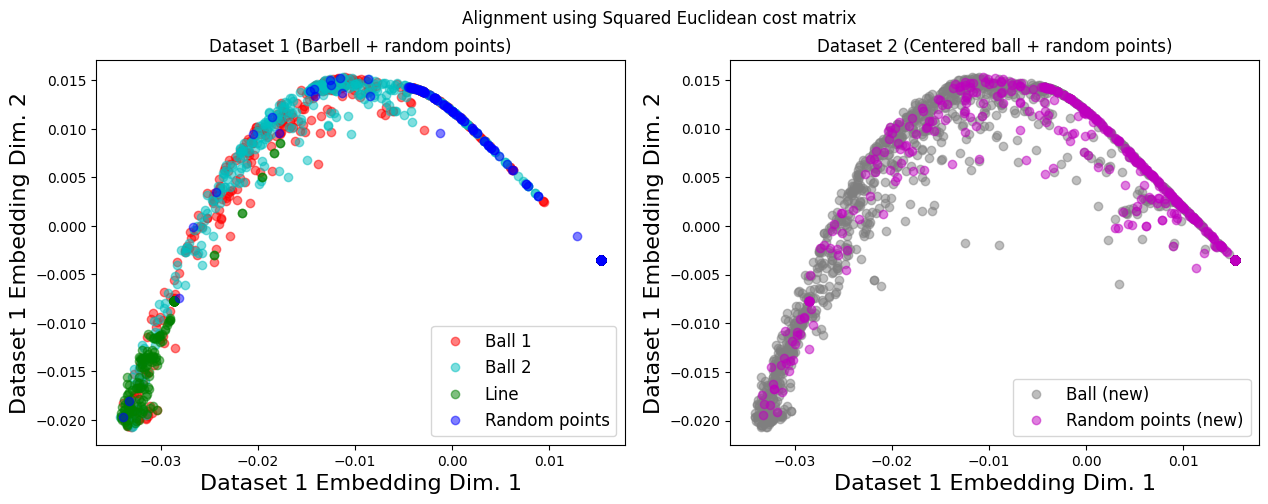

In [539]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

ax[0].plot(e1_norm[:len(blob1),0], e1_norm[:len(blob1),1], 'o', color='r', alpha=0.5, label="Ball 1")
ax[0].plot(e1_norm[len(blob1):(len(blob1) + len(blob2)),0], 
         e1_norm[len(blob1):(len(blob1) + len(blob2)),1], 'o', color='c', alpha=0.5, label="Ball 2")
ax[0].plot(e1_norm[(len(blob1) + len(blob2)):(len(blob1) + len(blob2) + len(line)),0], 
         e1_norm[(len(blob1) + len(blob2)):(len(blob1) + len(blob2) + len(line)),1], 'o',
           color='g', alpha=0.5, label="Line")
ax[0].plot(e1_norm[(len(blob1) + len(blob2) + len(line)):len(points),0],
        e1_norm[(len(blob1) + len(blob2) + len(line)):len(points),1], 'o', 
        color='b', alpha=0.5, label="Random points")
ax[1].plot(e2_aligned[:len(blob1_new),0],e2_aligned[:len(blob1_new),1], 'o', 
           color='tab:gray', alpha=0.5, label="Ball (new)")
ax[1].plot(e2_aligned[-len(rand_points_new):,0],e2_aligned[-len(rand_points_new):,1], 'o',
            color='m', alpha=0.5, label="Random points (new)")

ax[0].set_xlabel("Dataset 1 Embedding Dim. 1", fontsize=16)
ax[0].set_ylabel("Dataset 1 Embedding Dim. 2", fontsize=16)

ax[1].set_xlabel("Dataset 1 Embedding Dim. 1", fontsize=16)
ax[1].set_ylabel("Dataset 1 Embedding Dim. 2", fontsize=16)

ax[0].set_title("Dataset 1 (Barbell + random points)")
ax[1].set_title("Dataset 2 (Centered ball + random points)")

ax[0].legend(fontsize=12)
ax[1].legend(fontsize=12)
fig.suptitle("Alignment using Squared Euclidean cost matrix")
plt.show()

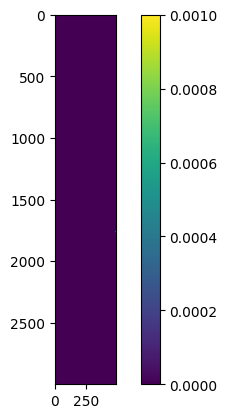

In [547]:
plt.imshow(sorted_vectors2[:,-500:], vmax = 0.001)
plt.colorbar()

In [548]:
def cost_matrix_neighborhoods(sorted_distance_vectors1, sorted_distance_vectors2):
    num_vectors1 = len(sorted_distance_vectors1[0])
    num_vectors2 = len(sorted_distance_vectors2[0])

    if num_vectors1 >= num_vectors2:
        similarity_distances = euclidean_distances(sorted_distance_vectors1[:,-num_vectors2:], sorted_distance_vectors2)
    else:
        similarity_distances = euclidean_distances(sorted_distance_vectors1, sorted_distance_vectors2[:,-num_vectors1:])
    
    return similarity_distances

In [549]:
cost_matrix_neighborhoods(sorted_vectors1, sorted_vectors2)

array([[0.24499811, 0.21000487, 0.28292513, ..., 0.21000487, 0.21000487,
        0.21000487],
       [0.65018106, 0.8086069 , 0.64974341, ..., 0.8086069 , 0.8086069 ,
        0.8086069 ],
       [0.25261478, 0.2023882 , 0.29054181, ..., 0.2023882 , 0.2023882 ,
        0.2023882 ],
       ...,
       [0.45500298, 0.        , 0.49293001, ..., 0.        , 0.        ,
        0.        ],
       [0.45500298, 0.        , 0.49293001, ..., 0.        , 0.        ,
        0.        ],
       [0.45500298, 0.        , 0.49293001, ..., 0.        , 0.        ,
        0.        ]])

(2200, 3) (3000, 3)
(2200, 3) (3000, 3) (2200, 3000) (2200, 3000)


/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:631: RuntimeWarning: divide by zero encountered in divide
  u = 1.0 / nx.dot(Kp, v)
/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:631: RuntimeWarning: overflow encountered in divide
  u = 1.0 / nx.dot(Kp, v)
/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


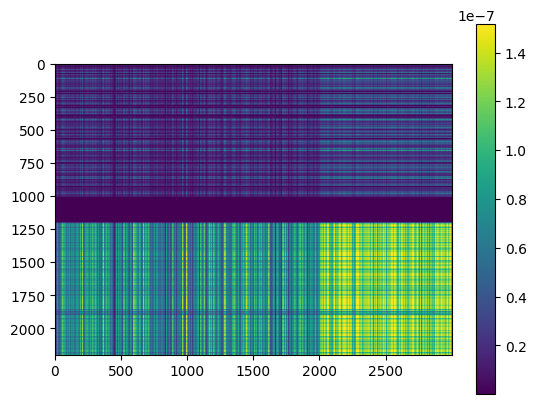

In [605]:
e1 = np.real(embedding[:, :3])    # Dataset 1: blobs + line + random
e2 = np.real(new_embedding[:, :3]) # Dataset 2: blob_new + random

# Step 1: Center both embeddings
e1_centered = e1 - e1.mean(axis=0)
e2_centered = e2 - e2.mean(axis=0)

# Step 2: Normalize scale (divide by Frobenius norm)
# e1_norm = e1_centered / np.linalg.norm(e1_centered, 'fro')
# e2_norm = e2_centered / np.linalg.norm(e2_centered, 'fro')

e1_norm = e1_centered / np.linalg.norm(e1_centered, 'fro')
e2_norm = e2_centered / np.linalg.norm(e2_centered, 'fro')

print(e1_norm.shape, e2_norm.shape)

regular_cost_matrix = ot.dist(e1_norm, e2_norm, metric='sqeuclidean')
similarity_cost_matrix = cost_matrix_neighborhoods(sorted_vectors1, sorted_vectors2)
# similarity_cost_matrix /= similarity_cost_matrix.sum(axis=1, keepdims=True)
# similarity_cost_matrix /= similarity_cost_matrix.sum(axis=0, keepdims=True)
similarity_cost_matrix /= np.linalg.norm(similarity_cost_matrix, 'fro')

C = similarity_cost_matrix**2
# Solve the OT problem
# sol = ot.solve(C) # assumed uniform weights

a = ot.utils.unif(e1.shape[0])  # weights of points in the source domain
b = ot.utils.unif(e2.shape[0])  # weights of points in the target domain

print(e1_norm.shape, e2_norm.shape, C.shape, (C / C.max()).shape)

ot_sinkhorn = ot.sinkhorn(a, b, M=C/C.max(), reg = 1e-4)

P = ot_sinkhorn
# get the OT plan
# P = sol.plan

# get the OT loss
# loss = sol.value

# print(f"OT loss = {loss:1.3f}")

plt.imshow(P,  vmin=1e-10)
plt.colorbar()
plt.show()


In [606]:
P_normalized = P / P.sum(axis=1, keepdims=True)  # each row sums to 1

# Transport: weighted average of x2 points for each x1 point
e1_aligned = P_normalized @ e2_norm  # shape (n1, 2)

P_normalized_T = P.T / P.T.sum(axis=1, keepdims=True)  # each row sums to 1

e2_aligned = P_normalized_T @ e1_norm

e1_aligned.shape

/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_1097/3646762841.py:1: RuntimeWarning: invalid value encountered in divide
  P_normalized = P / P.sum(axis=1, keepdims=True)  # each row sums to 1


(2200, 3)

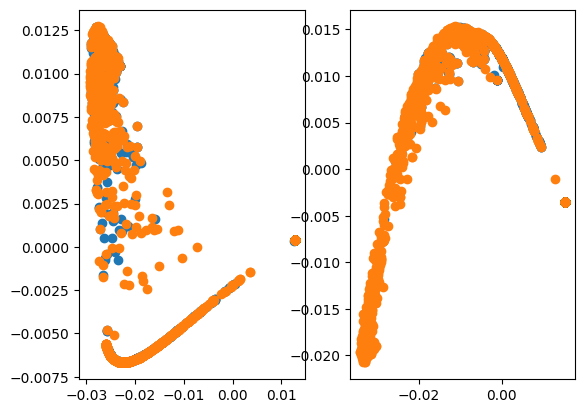

In [607]:
fig, ax = plt.subplots(1,2)

ax[0].plot(e1_aligned[:,0], e1_aligned[:,1], 'o')
ax[0].plot(e2_norm[:,0], e2_norm[:,1], 'o')
# plt.plot(e1_norm[:,0], e1_norm[:,1], 'o')

ax[1].plot(e2_aligned[:,0], e2_aligned[:,1], 'o')
ax[1].plot(e1_norm[:,0], e1_norm[:,1], 'o')

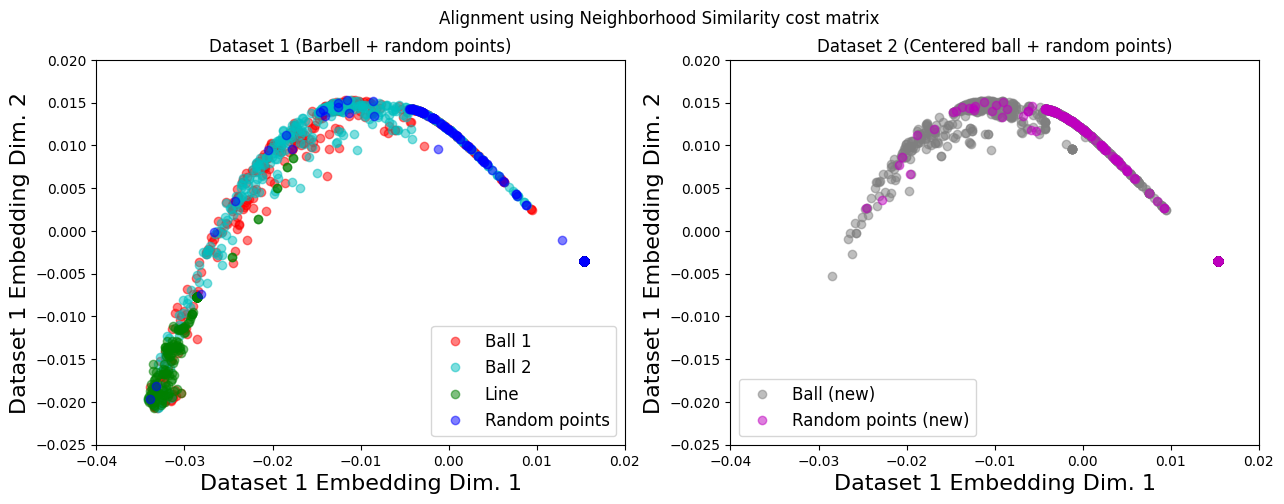

In [608]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

ax[0].plot(e1_norm[:len(blob1),0], e1_norm[:len(blob1),1], 'o', color='r', alpha=0.5, label="Ball 1")
ax[0].plot(e1_norm[len(blob1):(len(blob1) + len(blob2)),0], 
         e1_norm[len(blob1):(len(blob1) + len(blob2)),1], 'o', color='c', alpha=0.5, label="Ball 2")
ax[0].plot(e1_norm[(len(blob1) + len(blob2)):(len(blob1) + len(blob2) + len(line)),0], 
         e1_norm[(len(blob1) + len(blob2)):(len(blob1) + len(blob2) + len(line)),1], 'o',
           color='g', alpha=0.5, label="Line")
ax[0].plot(e1_norm[(len(blob1) + len(blob2) + len(line)):len(points),0],
        e1_norm[(len(blob1) + len(blob2) + len(line)):len(points),1], 'o', 
        color='b', alpha=0.5, label="Random points")
ax[1].plot(e2_aligned[:len(blob1_new),0],e2_aligned[:len(blob1_new),1], 'o', 
           color='tab:gray', alpha=0.5, label="Ball (new)")
ax[1].plot(e2_aligned[-len(rand_points_new):,0],e2_aligned[-len(rand_points_new):,1], 'o',
            color='m', alpha=0.5, label="Random points (new)")

ax[0].set_xlim(-0.04,0.02)
ax[1].set_xlim(-0.04,0.02)

ax[0].set_ylim(-0.025,0.02)
ax[1].set_ylim(-0.025,0.02)

ax[0].set_xlabel("Dataset 1 Embedding Dim. 1", fontsize=16)
ax[0].set_ylabel("Dataset 1 Embedding Dim. 2", fontsize=16)

ax[1].set_xlabel("Dataset 1 Embedding Dim. 1", fontsize=16)
ax[1].set_ylabel("Dataset 1 Embedding Dim. 2", fontsize=16)

ax[0].legend(fontsize=12)
ax[1].legend(fontsize=12)

ax[0].set_title("Dataset 1 (Barbell + random points)")
ax[1].set_title("Dataset 2 (Centered ball + random points)")

fig.suptitle("Alignment using Neighborhood Similarity cost matrix")

plt.show()

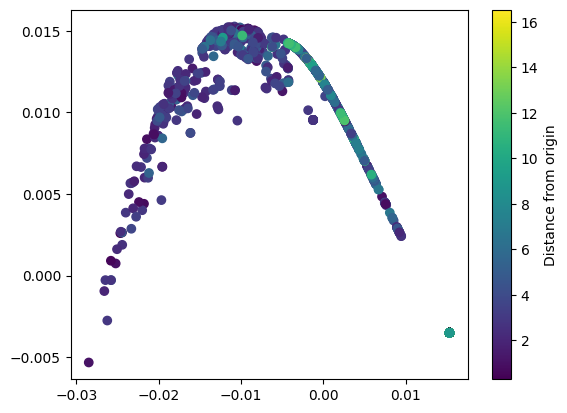

In [609]:
plt.scatter(e2_aligned[:,0], e2_aligned[:,1], c = np.sqrt(xs_new**2 + ys_new**2 + zs_new**2))
cbar = plt.colorbar()
cbar.set_label("Distance from origin")

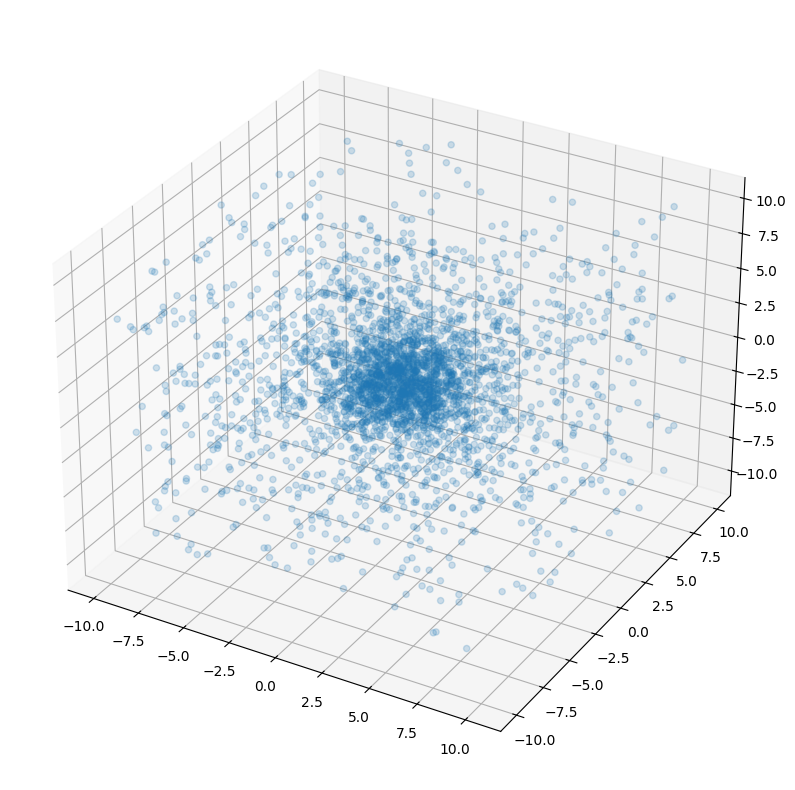

In [613]:
z_new1 = multivariate_normal(mean = [0,0,0], cov = 2*np.eye(3))
z_new2 = multivariate_normal(mean = [0,0,0], cov = 10*np.eye(3))

blob1_new1 = z_new1.rvs(1000)
blob1_new2 = z_new2.rvs(1000)

rand_points_new1 = np.random.uniform(-10, 10, (1000, 3))

points_new1 = np.vstack((blob1_new1, blob1_new2, rand_points_new1))

xs_new1, ys_new1, zs_new1 = points_new1[:,0], points_new1[:,1], points_new1[:,2]

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
ax.scatter(xs_new1, ys_new1, zs_new1, alpha=0.2)
plt.show()

Keeping 10 dimensions


/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/matplotlib/axes/_axes.py:4590: ComplexWarning: Casting complex values to real discards the imaginary part
  c = np.asanyarray(c, dtype=float)


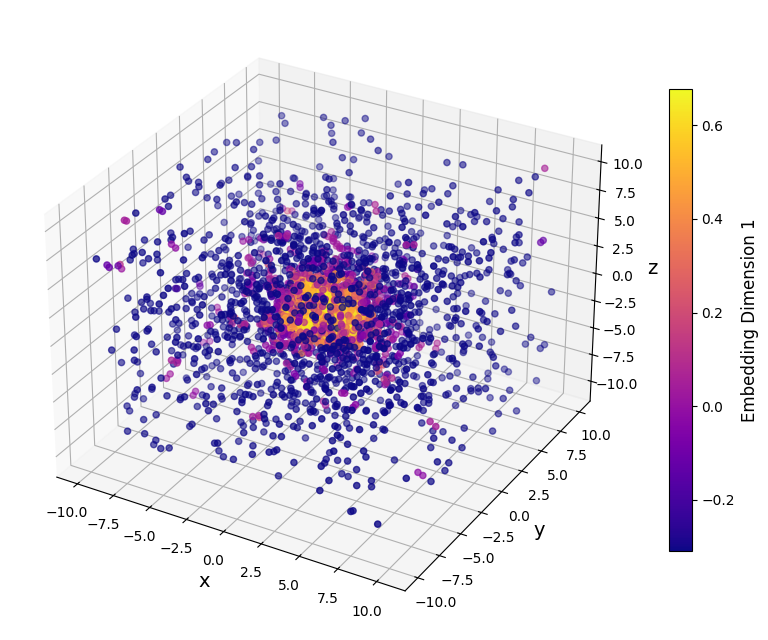

In [614]:
sorted_vectors3, new_embedding1 = create_embedding(xs_new1, ys_new1, zs_new1)
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
p = ax.scatter(xs_new1, ys_new1, zs_new1, c=new_embedding1[:,0], cmap='plasma')
# p = ax.scatter(xs, ys, zs, c=pca.components_[0])
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14)
cbar = fig.colorbar(p, ax=ax, shrink=0.6)
cbar.set_label("Embedding Dimension 1", fontsize=12)
plt.show()

In [615]:
def align_latent_spaces(embedding1, embedding2, sorted_vectors1, sorted_vectors2, 
                        reg=0.01, cost_type='neighborhood', normalize=True, 
                        return_both_directions=True):
    """
    Align latent spaces between two datasets using optimal transport.
    
    Parameters:
    -----------
    embedding1 : ndarray, shape (n1, d)
        Embedding of dataset 1
    embedding2 : ndarray, shape (n2, d)
        Embedding of dataset 2
    sorted_vectors1 : ndarray, shape (n1, k1)
        Sorted distance vectors for dataset 1 (from create_embedding)
    sorted_vectors2 : ndarray, shape (n2, k2)
        Sorted distance vectors for dataset 2 (from create_embedding)
    reg : float, default=0.01
        Entropy regularization parameter for Sinkhorn. 
        Smaller = sharper correspondences, larger = more diffuse.
        Recommended: 0.01 * C.mean() as a starting point.
    cost_type : str, default='neighborhood'
        Type of cost matrix to use:
        - 'neighborhood': uses sorted distance vectors (similarity of local environments)
        - 'euclidean': uses squared Euclidean distance in embedding space
    normalize : bool, default=True
        Whether to center and normalize embeddings before alignment
    return_both_directions : bool, default=True
        If True, returns both e1_aligned (in e2 space) and e2_aligned (in e1 space)
    
    Returns:
    --------
    dict with keys:
        'e1_aligned': embedding1 transported to embedding2's space
        'e2_aligned': embedding2 transported to embedding1's space (if return_both_directions)
        'e1_norm': normalized embedding1
        'e2_norm': normalized embedding2
        'P': transport plan matrix
        'cost_matrix': the cost matrix used
    """
    # Convert to real and take first 3 dimensions
    e1 = np.real(embedding1[:, :3])
    e2 = np.real(embedding2[:, :3])
    
    # Step 1: Center and normalize embeddings
    if normalize:
        e1_centered = e1 - e1.mean(axis=0)
        e2_centered = e2 - e2.mean(axis=0)
        e1_norm = e1_centered / np.linalg.norm(e1_centered, 'fro')
        e2_norm = e2_centered / np.linalg.norm(e2_centered, 'fro')
    else:
        e1_norm = e1
        e2_norm = e2
    
    # Step 2: Compute cost matrix
    if cost_type == 'neighborhood':
        # Use sorted distance vectors to compute similarity-based cost
        C = cost_matrix_neighborhoods(sorted_vectors1, sorted_vectors2)
        C = C / np.linalg.norm(C, 'fro')  # Normalize
        C = C ** 2  # Square for consistency with squared Euclidean
    elif cost_type == 'euclidean':
        C = ot.dist(e1_norm, e2_norm, metric='sqeuclidean')
    else:
        raise ValueError(f"cost_type must be 'neighborhood' or 'euclidean', got {cost_type}")
    
    # Normalize cost matrix for numerical stability
    C_normalized = C / C.max()
    
    # Step 3: Uniform weights
    a = ot.utils.unif(len(e1_norm))
    b = ot.utils.unif(len(e2_norm))
    
    # Step 4: Solve OT with Sinkhorn
    print(f"Running Sinkhorn with reg={reg}, cost_type='{cost_type}'")
    print(f"Cost matrix: shape={C.shape}, min={C.min():.6f}, max={C.max():.6f}, mean={C.mean():.6f}")
    
    P = ot.sinkhorn(a, b, M=C_normalized, reg=reg, numItermax=5000, warn=True)
    
    # Step 5: Transport embeddings using barycentric projection
    # Normalize P rows to get proper weighted average
    P_row_normalized = P / P.sum(axis=1, keepdims=True)
    e1_aligned = P_row_normalized @ e2_norm  # Transport e1 to e2's space
    
    result = {
        'e1_aligned': e1_aligned,
        'e1_norm': e1_norm,
        'e2_norm': e2_norm,
        'P': P,
        'cost_matrix': C,
        'reg': reg,
        'cost_type': cost_type
    }
    
    if return_both_directions:
        P_col_normalized = P.T / P.T.sum(axis=1, keepdims=True)
        e2_aligned = P_col_normalized @ e1_norm  # Transport e2 to e1's space
        result['e2_aligned'] = e2_aligned
    
    print(f"Alignment complete. Transport plan shape: {P.shape}")
    
    return result

In [627]:
result  = align_latent_spaces(embedding, new_embedding1, sorted_vectors1, sorted_vectors3, reg=1e-4, cost_type='neighborhood')
e3_aligned = result['e2_aligned']
e1_norm = result['e1_norm']

Running Sinkhorn with reg=0.0001, cost_type='neighborhood'
Cost matrix: shape=(2200, 3000), min=0.000000, max=0.000001, mean=0.000000
Alignment complete. Transport plan shape: (2200, 3000)


/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:631: RuntimeWarning: overflow encountered in divide
  u = 1.0 / nx.dot(Kp, v)
/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 249
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


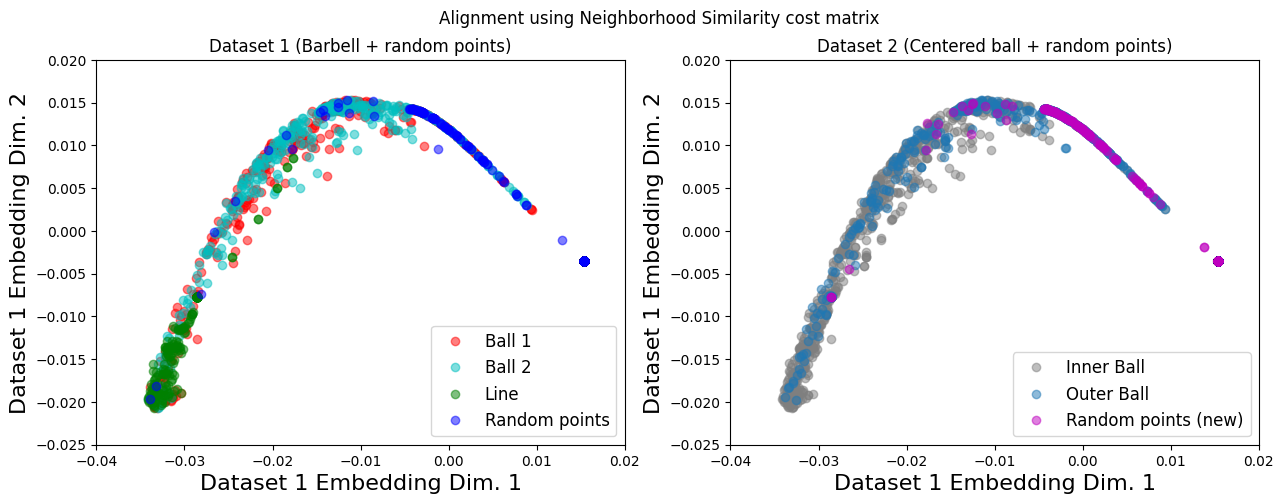

In [631]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

ax[0].plot(e1_norm[:len(blob1),0], e1_norm[:len(blob1),1], 'o', color='r', alpha=0.5, label="Ball 1")
ax[0].plot(e1_norm[len(blob1):(len(blob1) + len(blob2)),0], 
         e1_norm[len(blob1):(len(blob1) + len(blob2)),1], 'o', color='c', alpha=0.5, label="Ball 2")
ax[0].plot(e1_norm[(len(blob1) + len(blob2)):(len(blob1) + len(blob2) + len(line)),0], 
         e1_norm[(len(blob1) + len(blob2)):(len(blob1) + len(blob2) + len(line)),1], 'o',
           color='g', alpha=0.5, label="Line")
ax[0].plot(e1_norm[(len(blob1) + len(blob2) + len(line)):len(points),0],
        e1_norm[(len(blob1) + len(blob2) + len(line)):len(points),1], 'o', 
        color='b', alpha=0.5, label="Random points")

ax[1].plot(e3_aligned[:len(blob1_new1),0],e3_aligned[:len(blob1_new1),1], 'o', 
           color='tab:gray', alpha=0.5, label="Inner Ball")
ax[1].plot(e3_aligned[len(blob1_new1):(len(blob1_new1) + len(blob1_new2)),0],e3_aligned[len(blob1_new1):(len(blob1_new1) + len(blob1_new2)),1], 'o', 
           color='tab:blue', alpha=0.5, label="Outer Ball")
ax[1].plot(e3_aligned[-len(rand_points_new1):,0],e3_aligned[-len(rand_points_new1):,1], 'o',
            color='m', alpha=0.5, label="Random points (new)")

ax[0].set_xlim(-0.04,0.02)
ax[1].set_xlim(-0.04,0.02)

ax[0].set_ylim(-0.025,0.02)
ax[1].set_ylim(-0.025,0.02)

ax[0].set_xlabel("Dataset 1 Embedding Dim. 1", fontsize=16)
ax[0].set_ylabel("Dataset 1 Embedding Dim. 2", fontsize=16)

ax[1].set_xlabel("Dataset 1 Embedding Dim. 1", fontsize=16)
ax[1].set_ylabel("Dataset 1 Embedding Dim. 2", fontsize=16)

ax[0].legend(fontsize=12)
ax[1].legend(fontsize=12)

ax[0].set_title("Dataset 1 (Barbell + random points)")
ax[1].set_title("Dataset 2 (Centered ball + random points)")

fig.suptitle("Alignment using Neighborhood Similarity cost matrix")

plt.show()

Keeping 10 dimensions
Keeping 10 dimensions


/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/matplotlib/axes/_axes.py:4590: ComplexWarning: Casting complex values to real discards the imaginary part
  c = np.asanyarray(c, dtype=float)


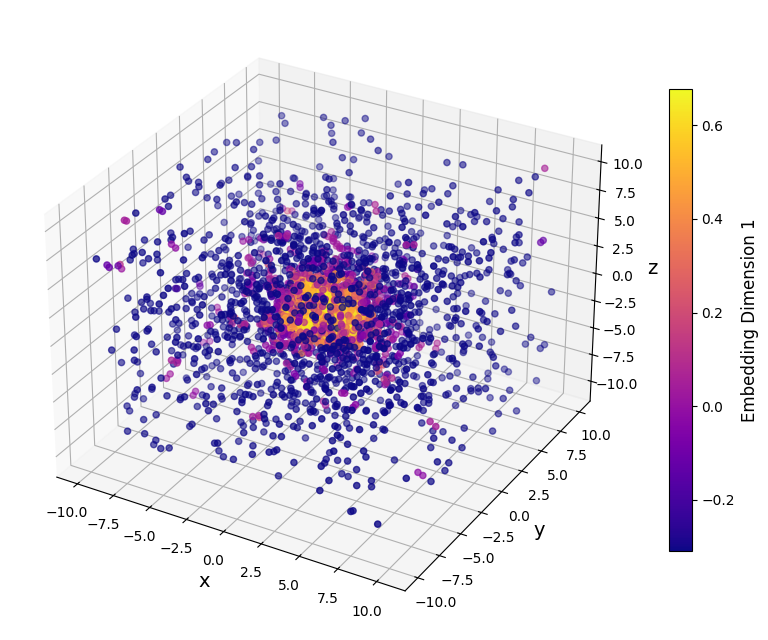

In [682]:
sorted_vectors1, e = create_embedding(xs, ys, zs, threshold = 0.5)
sorted_vectors3, new_embedding1 = create_embedding(xs_new1, ys_new1, zs_new1, threshold = 0.5)
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
p = ax.scatter(xs_new1, ys_new1, zs_new1, c=new_embedding1[:,0], cmap='plasma')
# p = ax.scatter(xs, ys, zs, c=pca.components_[0])
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14)
cbar = fig.colorbar(p, ax=ax, shrink=0.6)
cbar.set_label("Embedding Dimension 1", fontsize=12)
plt.show()

/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Embedding Dimension 2')

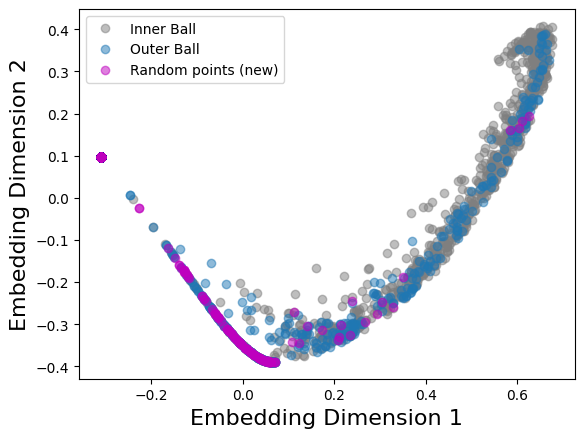

In [683]:
plt.plot(new_embedding1[:len(blob1_new1),0], new_embedding1[:len(blob1_new1),1], 'o', 
           color='tab:gray', alpha=0.5, label="Inner Ball")
plt.plot( new_embedding1[len(blob1_new1):(len(blob1_new1) + len(blob1_new2)),0], new_embedding1[len(blob1_new1):(len(blob1_new1) + len(blob1_new2)),1], 'o', 
           color='tab:blue', alpha=0.5, label="Outer Ball")
plt.plot( new_embedding1[-len(rand_points_new1):,0], new_embedding1[-len(rand_points_new1):,1], 'o',
            color='m', alpha=0.5, label="Random points (new)")

plt.legend()
plt.xlabel("Embedding Dimension 1", fontsize=16)
plt.ylabel("Embedding Dimension 2", fontsize=16)


In [684]:
result  = align_latent_spaces(embedding, new_embedding1, sorted_vectors1, sorted_vectors3, reg=1e-6, cost_type='neighborhood')
e3_aligned = result['e2_aligned']
e1_norm = result['e1_norm']

Running Sinkhorn with reg=1e-06, cost_type='neighborhood'
Cost matrix: shape=(2200, 3000), min=0.000000, max=0.000001, mean=0.000000
Alignment complete. Transport plan shape: (2200, 3000)


/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:630: RuntimeWarning: divide by zero encountered in divide
  v = b / KtransposeU
/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:630: RuntimeWarning: overflow encountered in divide
  v = b / KtransposeU
/Users/anasofiauzsoy/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_1097/1616253474.py:80: RuntimeWarning: invalid value encountered in divide
  P_row_normalized = P / P.sum(axis=1, keepdims=True)
/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_1097/1616253474.py:94: RuntimeWarning: invalid value encountered in divide
  P_col_normalized = P.T / P.T.sum(axis=1, keepdims=True)


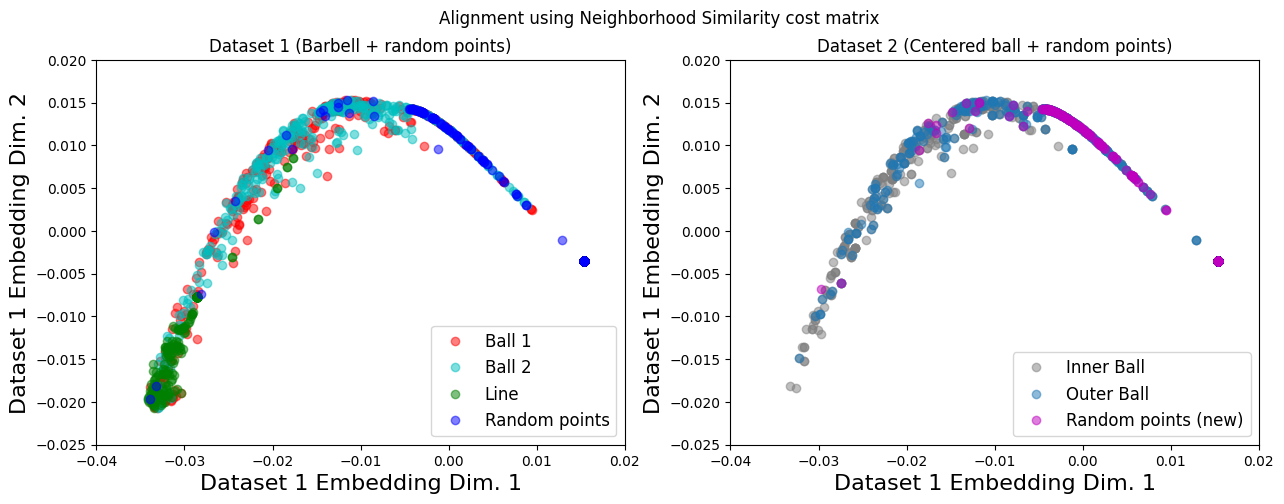

In [687]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

ax[0].plot(e1_norm[:len(blob1),0], e1_norm[:len(blob1),1], 'o', color='r', alpha=0.5, label="Ball 1")
ax[0].plot(e1_norm[len(blob1):(len(blob1) + len(blob2)),0], 
         e1_norm[len(blob1):(len(blob1) + len(blob2)),1], 'o', color='c', alpha=0.5, label="Ball 2")
ax[0].plot(e1_norm[(len(blob1) + len(blob2)):(len(blob1) + len(blob2) + len(line)),0], 
         e1_norm[(len(blob1) + len(blob2)):(len(blob1) + len(blob2) + len(line)),1], 'o',
           color='g', alpha=0.5, label="Line")
ax[0].plot(e1_norm[(len(blob1) + len(blob2) + len(line)):len(points),0],
        e1_norm[(len(blob1) + len(blob2) + len(line)):len(points),1], 'o', 
        color='b', alpha=0.5, label="Random points")

ax[1].plot(e3_aligned[:len(blob1_new1),0],e3_aligned[:len(blob1_new1),1], 'o', 
           color='tab:gray', alpha=0.5, label="Inner Ball")
ax[1].plot(e3_aligned[len(blob1_new1):(len(blob1_new1) + len(blob1_new2)),0],e3_aligned[len(blob1_new1):(len(blob1_new1) + len(blob1_new2)),1], 'o', 
           color='tab:blue', alpha=0.5, label="Outer Ball")
ax[1].plot(e3_aligned[-len(rand_points_new1):,0],e3_aligned[-len(rand_points_new1):,1], 'o',
            color='m', alpha=0.5, label="Random points (new)")

ax[0].set_xlim(-0.04,0.02)
ax[1].set_xlim(-0.04,0.02)

ax[0].set_ylim(-0.025,0.02)
ax[1].set_ylim(-0.025,0.02)

ax[0].set_xlabel("Dataset 1 Embedding Dim. 1", fontsize=16)
ax[0].set_ylabel("Dataset 1 Embedding Dim. 2", fontsize=16)

ax[1].set_xlabel("Dataset 1 Embedding Dim. 1", fontsize=16)
ax[1].set_ylabel("Dataset 1 Embedding Dim. 2", fontsize=16)

ax[0].legend(fontsize=12)
ax[1].legend(fontsize=12)

ax[0].set_title("Dataset 1 (Barbell + random points)")
ax[1].set_title("Dataset 2 (Centered ball + random points)")

fig.suptitle("Alignment using Neighborhood Similarity cost matrix")

plt.show()